In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('15-gym_crowdedness.csv')

In [3]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
#random forest regressor kullanılacak

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [6]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [7]:
df['date']=pd.to_datetime(df['date'],utc=True)

In [8]:
df['year']=df['date'].dt.year

In [9]:
df.drop('date',axis=1,inplace=True)

In [10]:
#EDA

C:\Users\Ömer faruk\AppData\Local\Temp\ipykernel_10328\2643889084.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df,x='hour',y='number_people',ci=None)


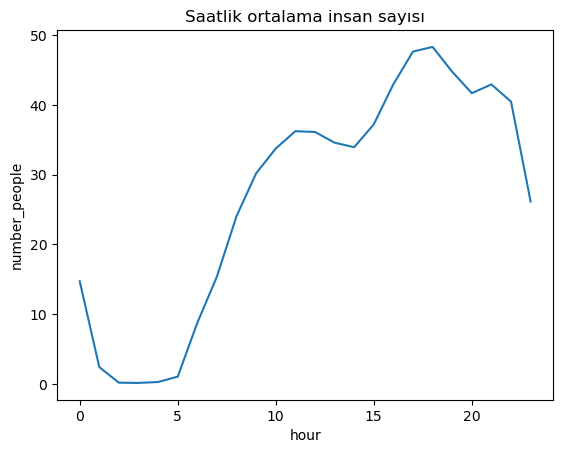

In [11]:
sns.lineplot(data=df,x='hour',y='number_people',ci=None)
plt.title('Saatlik ortalama insan sayısı')
plt.show()

C:\Users\Ömer faruk\AppData\Local\Temp\ipykernel_10328\3335501591.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df,x='day_of_week',y='number_people',ci=None)


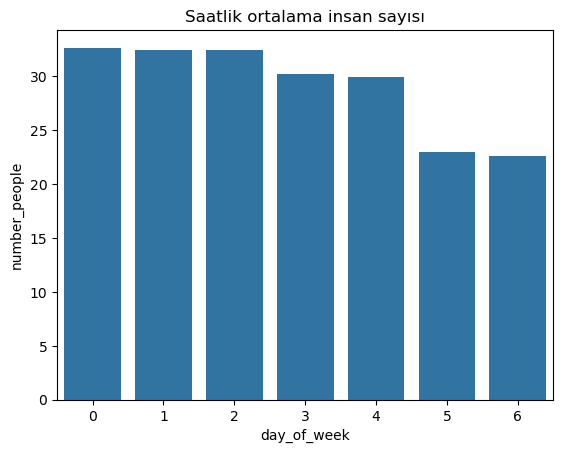

In [12]:
sns.barplot(data=df,x='day_of_week',y='number_people',ci=None)
plt.title('Saatlik ortalama insan sayısı')
plt.show()

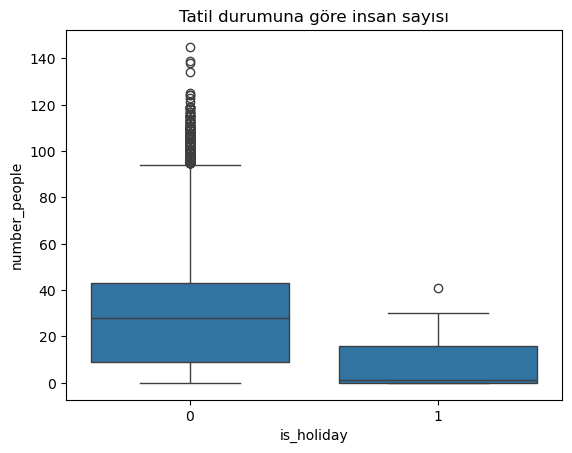

In [13]:
sns.boxplot(data=df,x='is_holiday',y='number_people')
plt.title('Tatil durumuna göre insan sayısı')
plt.show()

C:\Users\Ömer faruk\AppData\Local\Temp\ipykernel_10328\829920138.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df,x='month',y='number_people',ci=None)


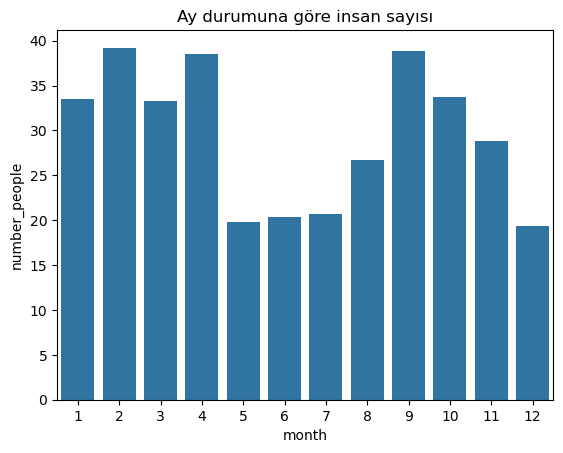

In [14]:
sns.barplot(data=df,x='month',y='number_people',ci=None)
plt.title('Ay durumuna göre insan sayısı')
plt.show()

<Axes: >

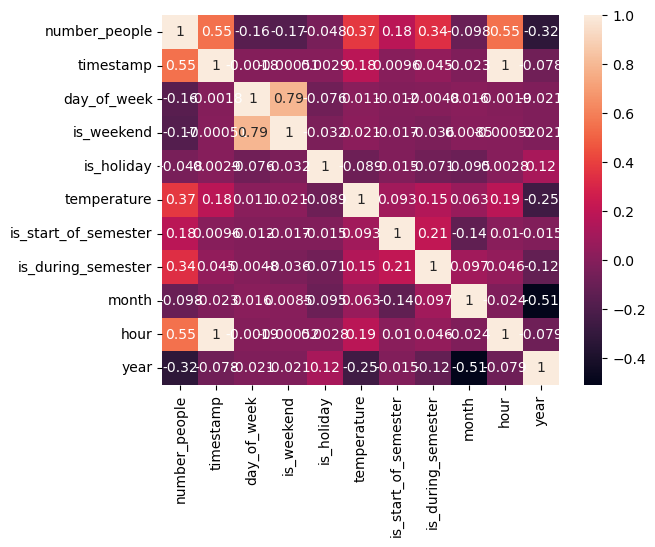

In [15]:
sns.heatmap(df.corr(),annot=True)

In [16]:
df.drop('timestamp',axis=1,inplace=True)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X=df.drop('number_people',axis=1)
y=df['number_people']

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler=StandardScaler()

In [23]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [33]:
def calculate_metrics(true,pred,model_name):
    mae=mean_absolute_error(true,pred)
    rmse=root_mean_squared_error(true,pred)
    r2=r2_score(true,pred)
    print(model_name)
    print(f'r^2 score: {r2}')
    print(f'mae score: {mae}')
    print(f'rmse score: {rmse}')
    print('--------------------')

In [34]:
models={

    'random_forest':RandomForestRegressor(),
    'linear_regression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge()

    
}

In [36]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    model_names=list(models.keys())[i]
    y_train_pred=model.predict(X_train)
    y_pred=model.predict(X_test)
    
    calculate_metrics(y_train,y_train_pred,model_names)
    calculate_metrics(y_test,y_pred,model_names)
    

random_forest
r^2 score: 0.9552870154611218
mae score: 3.253345952213802
rmse score: 4.795250270514995
--------------------
random_forest
r^2 score: 0.9260494336154309
mae score: 4.185902947262353
rmse score: 6.182328049395975
--------------------
linear_regression
r^2 score: 0.5981787302281028
mae score: 10.760973631267376
rmse score: 14.375101161567278
--------------------
linear_regression
r^2 score: 0.6059004497175824
mae score: 10.65730121562905
rmse score: 14.2719811492842
--------------------
Lasso
r^2 score: 0.5843258396584564
mae score: 10.96315615707611
rmse score: 14.620794158527497
--------------------
Lasso
r^2 score: 0.5915064622600906
mae score: 10.882606452898333
rmse score: 14.530276846265673
--------------------
Ridge
r^2 score: 0.5981787299516392
mae score: 10.76098113247104
rmse score: 14.375101166512499
--------------------
Ridge
r^2 score: 0.6059004688559221
mae score: 10.65731193575883
rmse score: 14.27198080274482
--------------------
